# ToBigs 정규세션 5주차 XAI 과제


# 1. Lime

In [1]:
!pip install lime

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   -------------- ------------------------- 4.5/12.0 MB 30.2 MB/s eta 0:00:01
   ---------------------------------------- 12.0/12.0 MB 34.4 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=284304 sha256=9996042e4477d0c1a77c41af406c0dbfef656c3db7e195797ab2b94248813c7d
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\eb\51\d9\c707b8fa7dee923cf3cb03edaf5c7f2bfeed5b91f5ca72f468
Successfully built lime

   ---------------------------------------- 0/5 [tifffile]
   ---------------------------------------- 0/5 [tifffile]
   ---------------- ---


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### LIME (Local Interpretable Model-agnostic Explanations) 실습
LIME은 모델의 종류와 상관없이(Model-agnostic) 특정 데이터 포인트의 예측 결과를 국소적으로(Local) 설명하는 기법입니다.

In [5]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime import lime_tabular

# 1. 데이터 로드 (유방암 데이터셋)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


In [3]:
# features
print(X.info())
print(y.shape)

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [12]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 분류 모델 생성 및 학습 (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


# LIME Explainer 초기화
explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=data.feature_names,
    class_names=data.target_names,
    mode='classification'
)

# 특정 데이터 샘플에 대해 설명 생성
# 테스트 셋의 첫 번째 데이터를 대상으로 설명 -> local explanation
i = 0
exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=rf_model.predict_proba,
    num_features=5 # 상위 5개 주요 feature만
)

# 결과 시각화
print(f'실제 라벨: {data.target_names[y_test[i]]}')
print(f'모델의 예측 확률: {rf_model.predict_proba(X_test.iloc[[i]])}')

# 노트북 내에서 시각화 결과 출력
exp.show_in_notebook(show_table=True)

KeyError: 0

Q1. LIME의 핵심 동작 과정에 대해서 서술해주세요.

답: LIME은 복잡한 블랙박스 모델을 직접 해석하는 대신, 특정 데이터 주변에서 단순한 모델로 근사하여 설명을 생성하는 방식이다. 먼저 원본 데이터 주변에서 입력을 조금씩 변형한 가짜 샘플을 생성하고, 각 샘플에 대해 원본과의 거리 기반 가중치를 부여한다. 이후 이 샘플들을 기존 블랙박스 모델에 넣어 예측값을 얻고, 중요하지 않은 특징을 제거한 뒤, 가중치가 반영된 선형 모델을 학습한다. 이렇게 학습된 단순 모델의 계수를 통해 각 feature가 예측에 얼마나 기여했는지를 설명한다.

Q2. LIME model에서의 surrogate model의 역할을 설명해주세요.

답: Surrogate model은 복잡한 원래 모델을 대신하여 특정 데이터 주변에서의 행동을 근사하는 해석용 모델이다. LIME에서는 이 surrogate model로 주로 선형 모델을 사용하며, 원본 모델의 예측 결과를 최대한 비슷하게 따라가도록 학습된다. 이를 통해 복잡한 모델의 내부 구조를 알지 못하더라도, surrogate model의 가중치를 해석함으로써 어떤 feature가 예측에 영향을 미쳤는지를 직관적으로 이해할 수 있다.

---

#2. SHAP

In [13]:
!pip install shap

   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   --------------------------------------- 559.2/559.2 kB 37.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   ---------- ----------------------------- 10.5/39.2 MB 57.7 MB/s eta 0:00:01
   ----------- ---------------------------- 11.0/39.2 MB 28.9 MB/s eta 0:00:01
   ------------- -------------------------- 13.6/39.2 MB 27.5 MB/s eta 0:00:01
   -------------- ------------------------- 14.4/39.2 MB 17.7 MB/s eta 0:00:02
   -------------------------- ------------- 25.7/39.2 MB 24.8 MB/s eta 0:00:01
   ------------------------------------- -- 37.0/39.2 MB 30.0 MB/s eta 0:00:01
   ---------------------------------------- 39.2/39.2 MB 29.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 49.4 MB/s eta 0:00:00

   -------- ------------------------------- 1/5 [llvmlite]
   -------- --------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### SHAP (SHapley Additive exPlanations)
SHAP은 게임 이론의 Shapley Value를 기반으로, 각 특성이 모델의 예측값에 얼마나 기여했는지를 수치화하여 설명하는 기법입니다.

C:\Users\user\OneDrive\문서\PyCharm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- 전체 데이터의 특성 중요도 (Summary Plot) ---


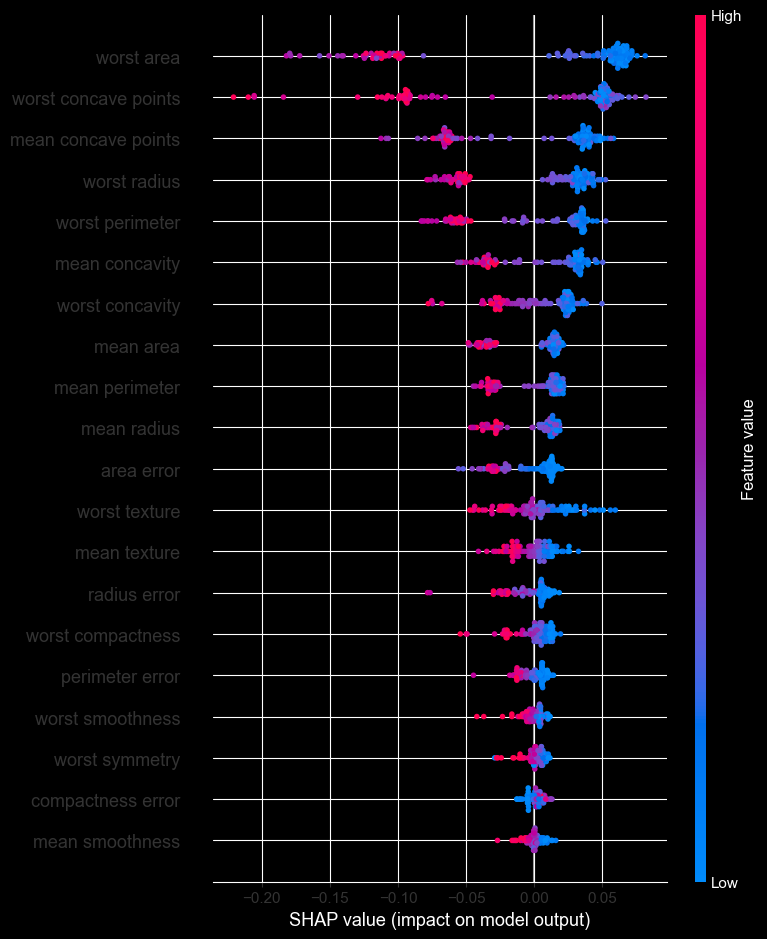

In [14]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# SHAP Explainer 초기화, ML 모델을 argument로
explainer_shap = shap.TreeExplainer(rf_model)

# SHAP Value 계산
shap_values = explainer_shap.shap_values(X_test)

# 결과 시각화 준비
if isinstance(shap_values, list):

    target_shap_values = shap_values[1]
    base_value = explainer_shap.expected_value[1]
else:
    if len(shap_values.shape) == 3:
        target_shap_values = shap_values[:, :, 1]
        base_value = explainer_shap.expected_value[1]
    else:
        target_shap_values = shap_values
        base_value = explainer_shap.expected_value

# Summary plot -> feature importance
print("--- 전체 데이터의 특성 중요도 (Summary Plot) ---")
shap.summary_plot(target_shap_values, X_test)


Q3. SHAP Value가 양수인 특성과 음수인 특성은 각각 예측 결과에 어떤 영향을 주는지 서술하세요.

답: SHAP value는 특정 feature가 예측값에 얼마나, 그리고 어떤 방향으로 기여했는지를 나타낸다. SHAP value가 양수인 경우, 해당 feature는 모델의 예측값을 기준값보다 증가시키는 방향으로 작용하며, 즉 특정 클래스에 대한 확률을 높이는 역할을 한다. 반대로 음수인 경우, 해당 feature는 예측값을 감소시키는 방향으로 작용하여 해당 클래스의 확률을 낮추거나 반대 결과로 밀어낸다. 따라서 SHAP value의 크기는 영향력의 정도를, 부호는 영향의 증감 방향을 의미한다.


Q4. 기존 Tree 기반 ML Model(RF)에서 사용하는 entropy 혹은 geni index 기반 feature importance와 SHAP의 feature importance의 차이점을 서술하세요.

답: 기존 Tree 기반 모델의 feature importance는 entropy나 gini index 감소량을 기반으로 계산되며, 이는 전체 데이터에 대한 평균적인 분할 기여도를 측정하는 방식이다. 따라서 특정 개별 데이터에 대해 feature가 어떤 영향을 주었는지는 알기 어렵고, feature 간 상호작용이나 공정한 기여 분배도 반영되지 않는 한계가 있다. 반면 SHAP은 게임 이론 기반의 Shapley value를 활용하여 각 feature의 기여도를 모든 가능한 조합에서의 평균적인 한계 기여로 계산하며, 개별 예측에 대한 local explanation과 전체 데이터에 대한 global 해석을 모두 제공한다.

---

# 3. Grad-CAM

### Grad-CAM (Gradient-weighted Class Activation Mapping)
Grad-CAM은 CNN 기반의 딥러닝 모델이 이미지의 어떤 영역을 보고 특정 클래스로 분류했는지를 중요도에 따라 히트맵(Heatmap) 형태로 시각화하는 기법입니다. 특성 맵(Feature Map)에 흐르는 그래디언트 정보를 사용하여 가중치를 계산합니다.

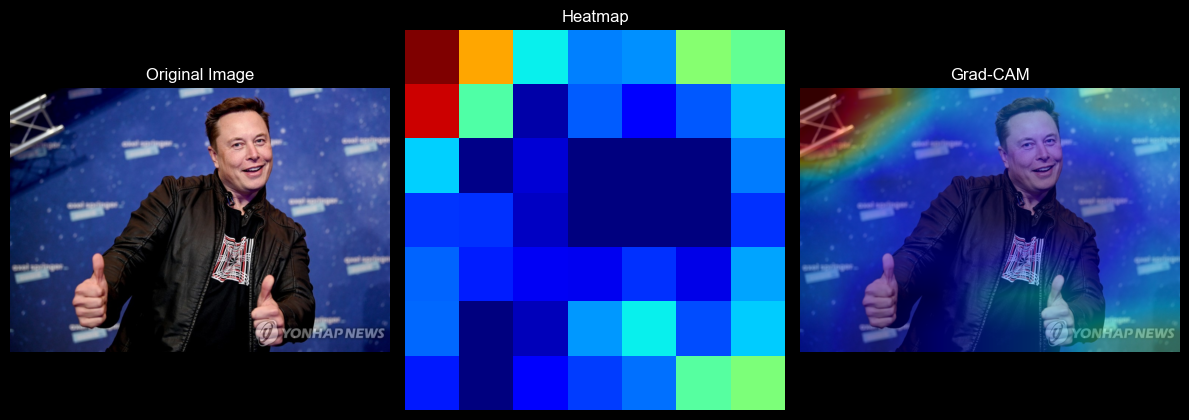

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
from io import BytesIO

# 1. 사전 학습된 모델 로드 (VGG16)
# weights 매개변수를 사용하여 최신 방식으로 로드합니다.
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval()

# 그래디언트와 특성 맵을 저장할 변수
gradients = None
activations = None

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

def forward_hook(module, input, output):
    global activations
    activations = output

# 마지막 컨볼루션 층에 훅 등록 (VGG16의 경우 features의 30번 레이어)
target_layer = model.features[30]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# 2. 이미지 로드 및 전처리
url = 'https://img2.yna.co.kr/photo/etc/epa/2020/12/02/PEP20201202052601055_P4.jpg'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

# 3. 모델 예측 및 Grad-CAM 계산
output = model(input_tensor)
pred_index = output.argmax(dim=1).item()

# 역전파 수행
model.zero_grad()
output[0, pred_index].backward()

# 4. Grad-CAM 히트맵 생성
# 글로벌 평균 풀링 (GAP)을 통한 가중치 미분값 계산
weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

# 특성 맵과 가중치 결합
heatmap = torch.sum(weights * activations, dim=1).squeeze()
heatmap = F.relu(heatmap) # ReLU 적용 (양의 영향만 고려)

# 0~1 사이 정규화
if torch.max(heatmap) != 0:
    heatmap /= torch.max(heatmap)
heatmap = heatmap.detach().cpu().numpy()

# 5. 결과 시각화
img_cv = np.array(img)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)

# 히트맵 리사이즈 및 컬러맵 적용
heatmap_resized = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# 원본과 합성 (Bayer 변환 고려)
superimposed_img = cv2.addWeighted(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB), 0.6, cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB), 0.4, 0)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Heatmap')
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Grad-CAM')
plt.imshow(superimposed_img)
plt.axis('off')

plt.tight_layout()
plt.show()

Q5. Grad-CAM에서 마지막 컨볼루션 층(Last Conv Layer)의 정보를 사용하는 이유는 무엇인가요?

답: Grad-CAM에서 마지막 컨볼루션 층을 사용하는 이유는 이 층이 공간적 위치 정보와 고수준 의미 정보를 동시에 유지하고 있기 때문이다. 초기 층은 저수준 특징을 주로 담고 있고, 완전연결층은 공간 정보를 잃어버리기 때문에 시각화에 적합하지 않다. 반면 마지막 Conv Layer는 객체의 위치를 어느 정도 보존하면서도 의미 있는 특징을 추출한 상태이기 때문에, 모델이 어떤 영역을 근거로 판단했는지를 시각적으로 표현하기에 가장 적절하다.

Q6. Grad-CAM 결과에서 붉게 표시되는 영역(High Activation)은 모델 판단에 어떤 의미를 갖는지 서술하세요.

답: Grad-CAM 결과에서 붉게 표시되는 영역은 해당 위치가 모델의 특정 클래스 예측에 강하게 기여한 부분을 의미한다. 즉, 모델이 해당 영역의 특징을 중요하게 사용하여 최종 판단을 내렸다는 뜻이다. 붉은 영역은 단순한 시각적 강조가 아니라, 모델의 의사결정 근거가 집중된 영역이라고 해석할 수 있다.

Q7. Grad-CAM 으로 시각화 한 heatmap이 과연 이미지의 중요한 객체를 담고 있는지 서술하세요. 만약 아니라면 본인이 생각하는 이유를 작성해주세요.

답: Grad-CAM으로 생성된 heatmap이 항상 실제 중요한 객체를 정확히 반영한다고 보장할 수는 없다. 모델이 학습 과정에서 bias나 배경 정보에 의존하는 패턴을 학습했을 경우, 객체가 아닌 배경에 높은 활성화가 나타날 수 있다. 또한 Grad-CAM은 특정 층의 gradient 기반 근사이기 때문에 해상도가 낮고 세밀한 구조를 정확히 반영하지 못하는 한계도 존재한다.

---

## Quantifying Attention Flow in Transformers 논문 실험해보기(Image)


논문에서 제시된 Attention Rollout을 구현해 분석해보겠습니다.

In [1]:
# 이미지 로드 및 전처리
import requests
from PIL import Image
from io import BytesIO
import torchvision.transforms as transforms

url = 'https://blog.kakaocdn.net/dna/cyD9pn/btsOxFfpiiW/AAAAAAAAAAAAAAAAAAAAAFGiOvHL_qlCUiUiUIg1JagJFnkaarNn8GiOBCO__hEp/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1774969199&allow_ip=&allow_referer=&signature=yWd4YCmf%2B1q9tAkMCHkW0O6PyJQ%3D'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x0000028460D928E0>

In [8]:
from transformers import ViTForImageClassification, ViTConfig

# 모델 설정에서 output_attentions를 명시적으로 True로 설정
config = ViTConfig.from_pretrained("google/vit-base-patch16-224", output_attentions=True)
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224", config=config)

device = torch.device("cpu")
model = model.to(device)
input_tensor = input_tensor.to(device)
model.eval()

with torch.no_grad():
    # 모델 호출 시에도 다시 한 번 명시
    outputs = model(input_tensor, output_attentions=True)

# Attention 추출
attentions = outputs.attentions

if attentions is not None:
    print(f"num_layers: {len(attentions)}")
    print(f"attention shape of one layer: {attentions[0].shape}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

num_layers: 12
attention shape of one layer: torch.Size([1, 12, 197, 197])


In [9]:
# rollout function
def attention_rollout(attentions):
    """
    attentions:
        tuple/list of attention tensors
        each tensor shape = (B, H, N, N)

    return:
        rollout: (B, N, N)
    """
    batch_size = attentions[0].shape[0]
    num_tokens = attentions[0].shape[-1]
    device = attentions[0].device

    # 초기값: identity 행렬(torch.eye)
    rollout = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)

    for attention in attentions:
        # 1) head fusion: mean(N개의 Attention Head를 어떻게 aggregation 할지, 여기서는 평균)
        attn = attention.mean(dim=1)   # (B, N, N)

        # 2) residual connection 반영(identity matrix를 더함)
        I = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)
        attn = attn + I

        # 3) row normalization(행의 합을 1로 맞춰줌)
        attn = attn / attn.sum(dim=-1, keepdim=True)

        # 4) rollout: 계속 곱함
        rollout = torch.bmm(attn, rollout)

    return rollout

In [10]:
with torch.no_grad():
    outputs = model(input_tensor, output_attentions=True)

attentions = outputs.attentions

print("num_layers:", len(attentions))
print("one attention shape:", attentions[0].shape)

num_layers: 12
one attention shape: torch.Size([1, 12, 197, 197])


In [15]:
# Rollout 계산
rollout = attention_rollout(attentions)   # (B, N, N)

# 첫 번째 배치 사용
rollout_map = rollout[0]   # (N, N)

# CLS token -> patch tokens
cls_attention = rollout_map[0, 1:]   # (num_patches,)

In [16]:
# patch map으로 변환
num_patches = cls_attention.shape[0]
grid_size = int(np.sqrt(num_patches))

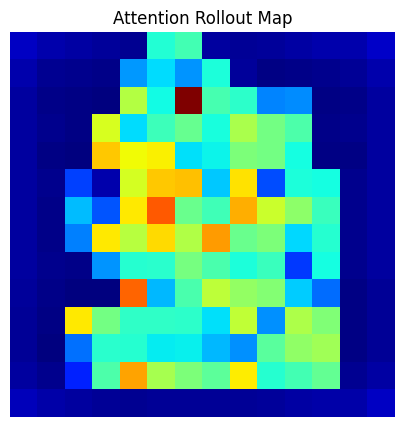

In [25]:
mask = cls_attention.reshape(grid_size, grid_size).detach().cpu().numpy()

# 0~1 정규화
mask = mask - mask.min()
mask = mask / (mask.max() + 1e-8)

# heatmap 시각화
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout Map")
plt.axis("off")
plt.show()


# 원본 이미지 복원(input_tensor가 normalize 되었기 때문에 다시 복원)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
def denormalize_image(img_tensor, mean, std):
    """
    img_tensor: (3, H, W)
    """
    mean = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    return img
img = denormalize_image(input_tensor[0], mean, std)
img = img.permute(1, 2, 0).detach().cpu().numpy()   # (H, W, 3)



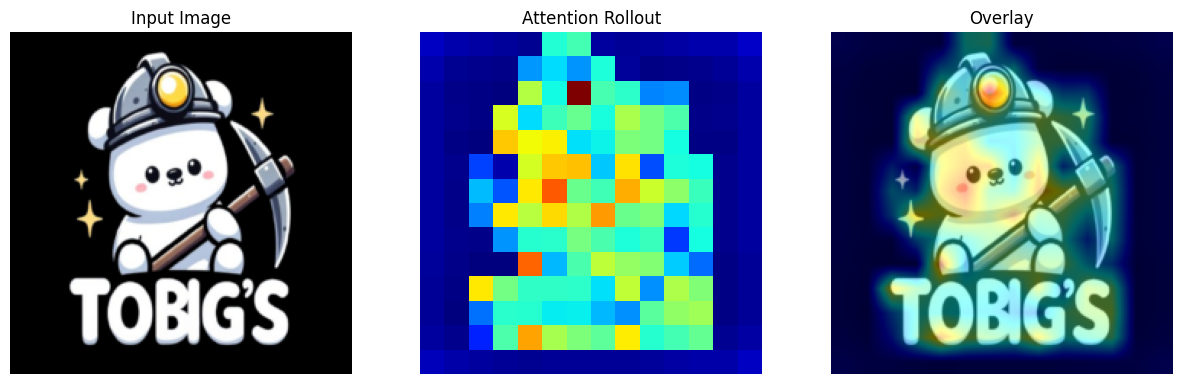

In [24]:
# 그림 시각화
H, W, _ = img.shape
mask_resized = cv2.resize(mask, (W, H))

heatmap = cv2.applyColorMap(np.uint8(255 * mask_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

overlay = 0.6 * img + 0.4 * heatmap
overlay = np.clip(overlay, 0, 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()

Q8. 기존의 Attention Score 기반 explanation 말고 위와 같은 Attention rollout 방법을 사용하는 이유를 알려주세요.

답: 기존의 Attention Score 기반 해석은 각 레이어에서의 attention만을 개별적으로 바라보기 때문에, 입력 토큰이 최종 출력에 어떻게 영향을 전달했는지를 전체적으로 파악하기 어렵다는 한계가 있다. Transformer는 여러 층을 거치면서 정보가 계속 섞이고 전달되는데, 단일 레이어의 attention만 보면 이러한 정보 흐름의 누적 효과를 반영하지 못한다. 반면 Attention Rollout은 여러 레이어의 attention을 순차적으로 결합하여 입력에서 출력까지의 전체적인 정보 전달 경로를 추적할 수 있게 해준다. 이를 통해 모델이 어떤 입력 토큰에 최종적으로 의존하고 있는지를 더 정확하게 파악할 수 있어, 단순 attention score보다 더 신뢰성 있는 해석을 제공한다.

(Optional) Q9. Attention Score를 기반으로 해석한, Score가 높은 word token 혹은 patch token으로 어떤 방법론을 만들 수 있을까요?(EX. ViT에서 Attention Score가 높은 patch token들을 따로 모아서 세밀한 부분을 구별하는 discriminative features로 사용 등)

답: Attention Score가 높은 토큰이나 패치를 활용하면 모델이 중요하게 보는 부분을 기반으로 다양한 응용이 가능하다. 예를 들어 ViT에서는 attention이 높은 patch token들을 선택하여 이미지의 핵심 영역만 집중적으로 분석하거나, 이를 통해 discriminative feature를 추출하여 분류 성능을 향상시킬 수 있다. 또한 NLP에서는 attention이 높은 단어를 기반으로 키워드 추출, 요약, 또는 설명 생성에 활용할 수 있으며, 중요한 토큰만 남기고 나머지를 제거하여 모델 경량화나 효율적인 inference에도 사용할 수 있다.